In [1]:
import xml.etree.ElementTree as ET
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Configuration
BASE_PATH = Path('C:/Users/athar/OneDrive/Documents/Sapan\'s Project/SUMO/output')
BASELINE_FILES = {
    'tripinfo': BASE_PATH/'baseline/tripinfo.xml',
    'emissions': BASE_PATH/'baseline/emissions.xml'
}
RAIN_FILES = {
    'tripinfo': BASE_PATH/'rain/tripinfo.xml',
    'emissions': BASE_PATH/'rain/emissions.xml'
}

# Helper function to parse tripinfo files
def parse_tripinfo(file_path):
    tree = ET.parse(file_path)
    root = tree.getroot()
    
    vehicles = []
    pedestrians = []
    
    for element in root:
        if element.tag == 'tripinfo':
            vehicles.append({
                'id': element.get('id'),
                'depart': float(element.get('depart')),
                'duration': float(element.get('duration')),
                'routeLength': float(element.get('routeLength')),
                'timeLoss': float(element.get('timeLoss')),
                'waitingTime': float(element.get('waitingTime')),
                'speedFactor': float(element.get('speedFactor')),
                'CO2': float(element.find('emissions').get('CO2_abs')),
                'fuel': float(element.find('emissions').get('fuel_abs')),
                'NOx': float(element.find('emissions').get('NOx_abs'))
            })
        elif element.tag == 'personinfo':
            walk = element.find('walk')
            pedestrians.append({
                'id': element.get('id'),
                'duration': float(element.get('traveltime')),
                'routeLength': float(walk.get('routeLength')),
                'timeLoss': float(walk.get('timeLoss')),
                'maxSpeed': float(walk.get('maxSpeed'))
            })
    
    return pd.DataFrame(vehicles), pd.DataFrame(pedestrians)

# Load data
baseline_vehicles, baseline_peds = parse_tripinfo(BASELINE_FILES['tripinfo'])
rain_vehicles, rain_peds = parse_tripinfo(RAIN_FILES['tripinfo'])

# Add scenario labels
baseline_vehicles['scenario'] = 'Baseline'
rain_vehicles['scenario'] = 'Rain Adaptive'
baseline_peds['scenario'] = 'Baseline'
rain_peds['scenario'] = 'Rain Adaptive'

# Combine datasets
all_vehicles = pd.concat([baseline_vehicles, rain_vehicles])
all_peds = pd.concat([baseline_peds, rain_peds])

# Calculate derived metrics
all_vehicles['avg_speed'] = all_vehicles['routeLength'] / all_vehicles['duration']
all_peds['avg_speed'] = all_peds['routeLength'] / all_peds['duration']

# Set up visualization style
sns.set_theme(style="darkgrid")  # Or use 'whitegrid', 'ticks', etc.
sns.set_palette("husl")
%matplotlib inline

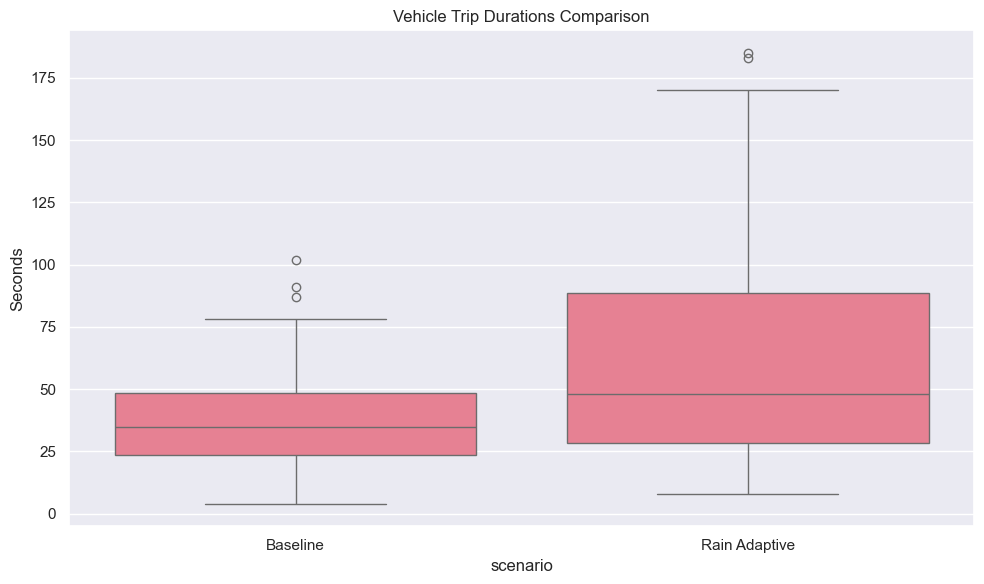

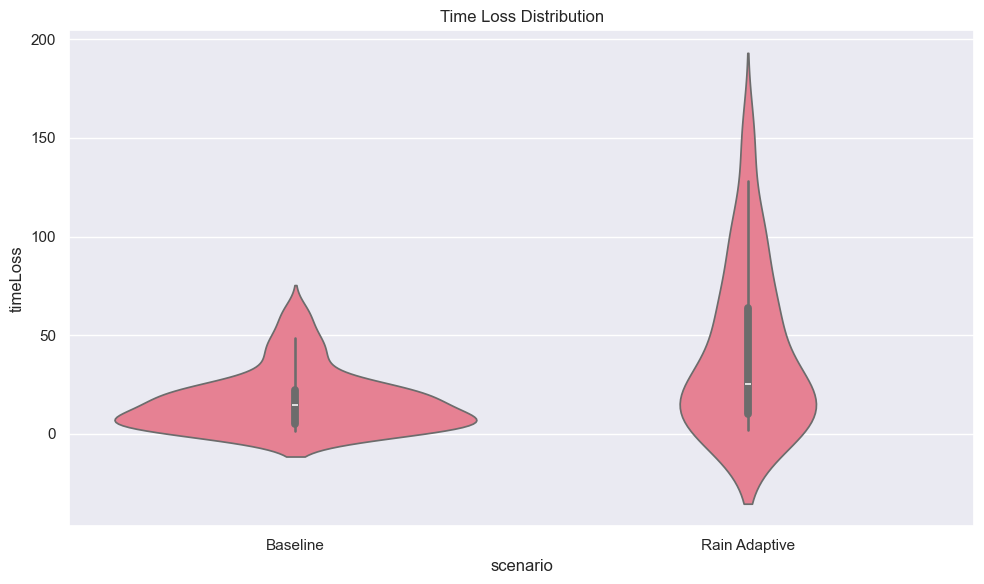

<Figure size 1000x600 with 0 Axes>

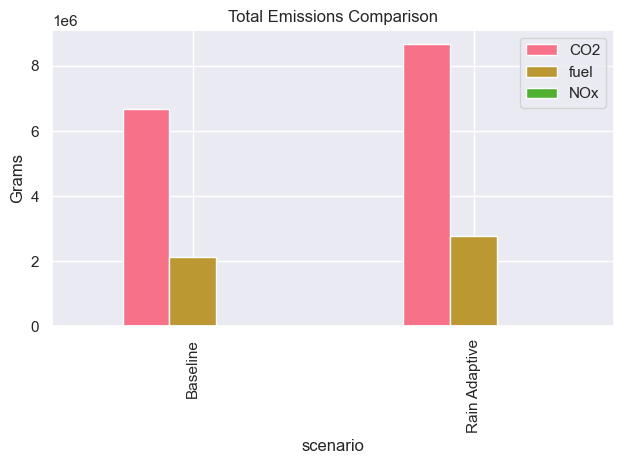

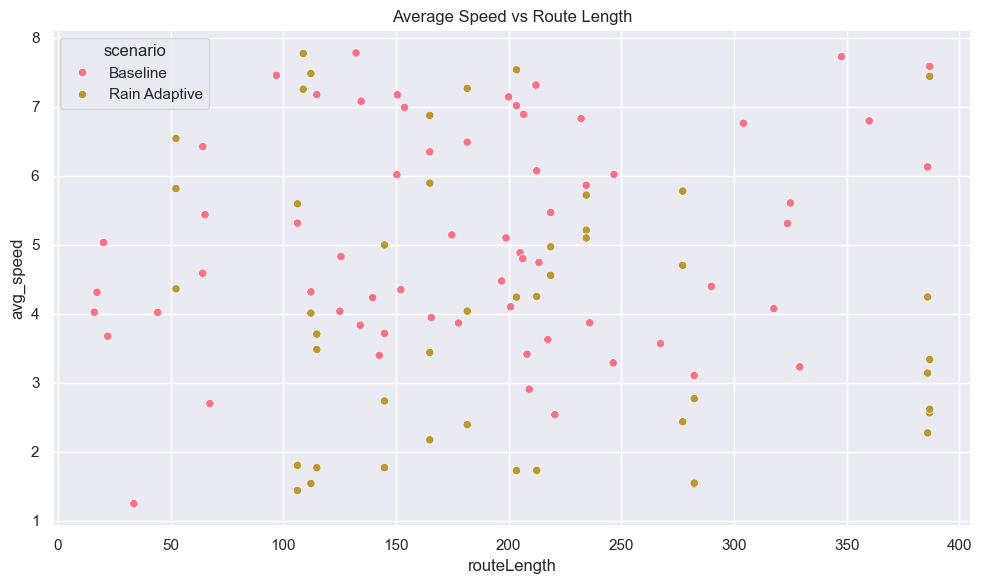

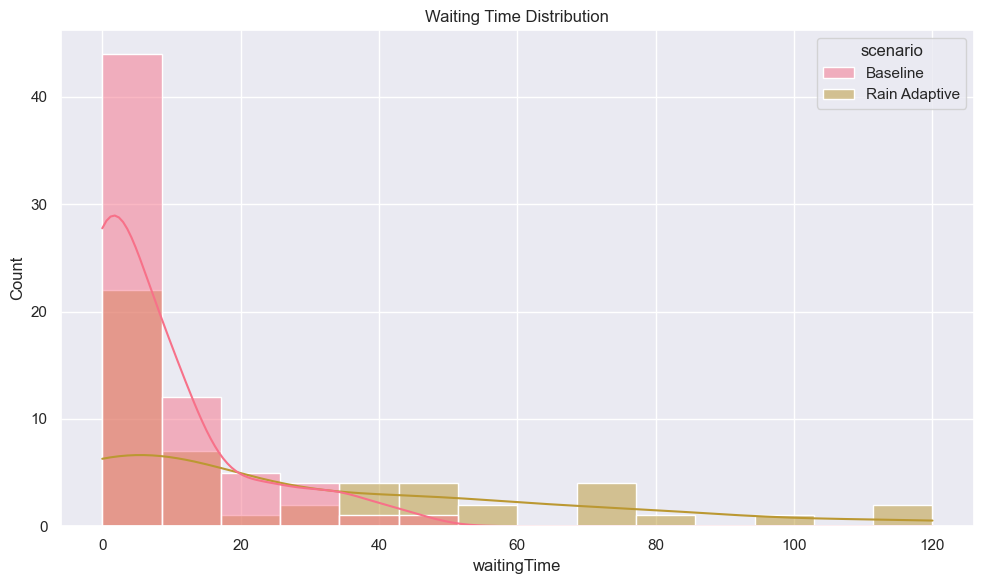

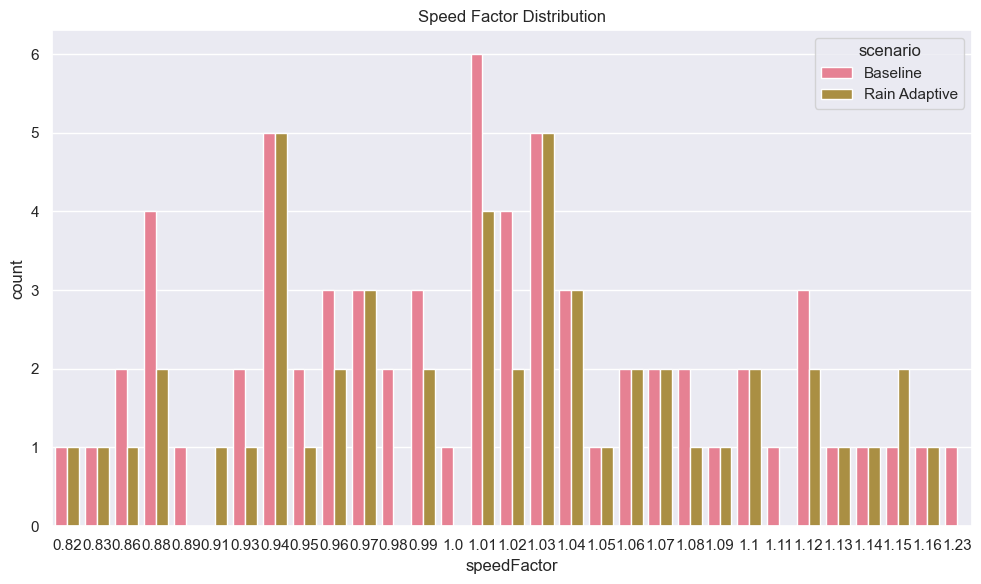

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Travel Time Comparison (Boxplot)
plt.figure(figsize=(10, 6))
sns.boxplot(x='scenario', y='duration', data=all_vehicles)
plt.title('Vehicle Trip Durations Comparison')
plt.ylabel('Seconds')
plt.tight_layout()
plt.savefig('travel_time_comparison.png')
plt.show()
plt.close()

# 2. Time Loss Analysis (Violin Plot)
plt.figure(figsize=(10, 6))
sns.violinplot(x='scenario', y='timeLoss', data=all_vehicles)
plt.title('Time Loss Distribution')
plt.tight_layout()
plt.savefig('time_loss_distribution.png')
plt.show()
plt.close()

# 3. Emissions Comparison (Bar Chart)
plt.figure(figsize=(10, 6))
emissions_compare = all_vehicles.groupby('scenario')[['CO2', 'fuel', 'NOx']].sum()
emissions_compare.plot(kind='bar')
plt.title('Total Emissions Comparison')
plt.ylabel('Grams')
plt.tight_layout()
plt.savefig('emissions_comparison.png')
plt.show()
plt.close()

# 4. Speed Analysis (Scatter Plot)
plt.figure(figsize=(10, 6))
sns.scatterplot(x='routeLength', y='avg_speed', hue='scenario', data=all_vehicles)
plt.title('Average Speed vs Route Length')
plt.tight_layout()
plt.savefig('speed_analysis.png')
plt.show()
plt.close()

# 5. Waiting Time Distribution (Histogram)
plt.figure(figsize=(10, 6))
sns.histplot(data=all_vehicles, x='waitingTime', hue='scenario', kde=True)
plt.title('Waiting Time Distribution')
plt.tight_layout()
plt.savefig('waiting_time_distribution.png')
plt.show()
plt.close()

# 6. Speed Factor Analysis (Count Plot)
plt.figure(figsize=(10, 6))
sns.countplot(x='speedFactor', hue='scenario', data=all_vehicles)
plt.title('Speed Factor Distribution')
plt.tight_layout()
plt.savefig('speed_factor_distribution.png')
plt.show()
plt.close()

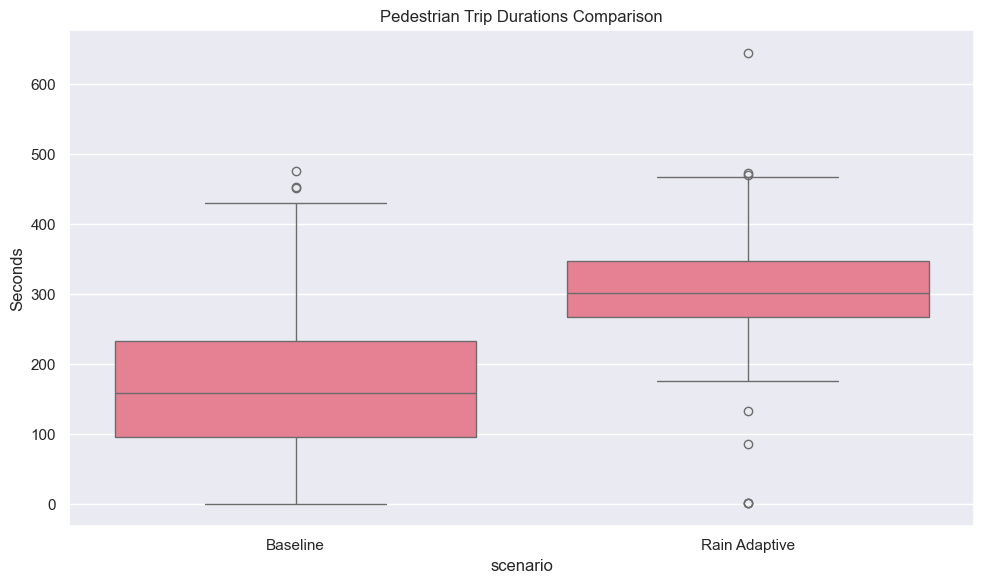

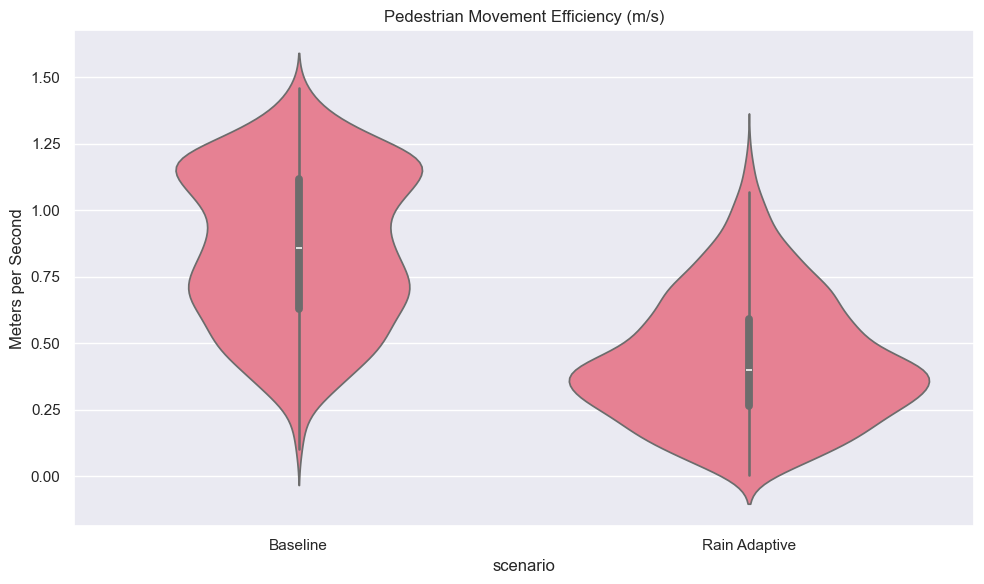

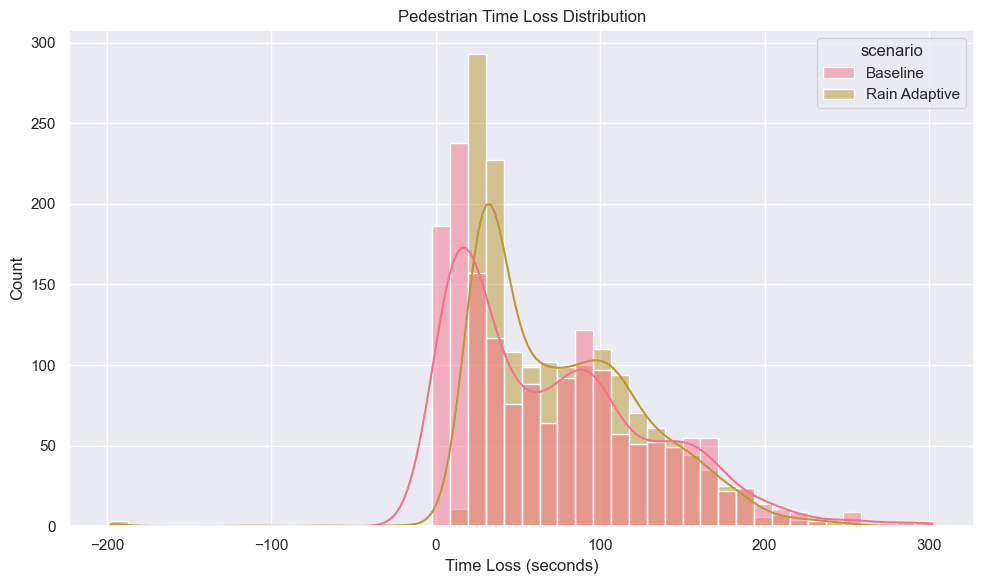

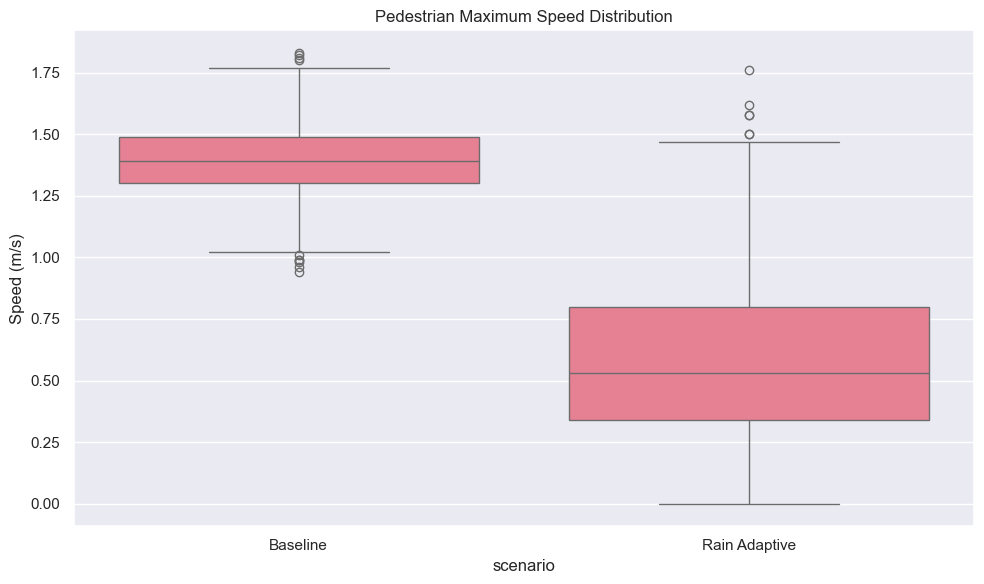

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Pedestrian Trip Durations (Boxplot)
plt.figure(figsize=(10, 6))
sns.boxplot(x='scenario', y='duration', data=all_peds)
plt.title('Pedestrian Trip Durations Comparison')
plt.ylabel('Seconds')
plt.tight_layout()
plt.savefig('pedestrian_trip_durations.png')
plt.show()
plt.close()

# 2. Movement Efficiency (Violin Plot)
plt.figure(figsize=(10, 6))
all_peds['efficiency'] = all_peds['routeLength'] / all_peds['duration']
sns.violinplot(x='scenario', y='efficiency', data=all_peds)
plt.title('Pedestrian Movement Efficiency (m/s)')
plt.ylabel('Meters per Second')
plt.tight_layout()
plt.savefig('pedestrian_efficiency.png')
plt.show()
plt.close()

# 3. Time Loss Distribution (Histogram)
plt.figure(figsize=(10, 6))
sns.histplot(data=all_peds, x='timeLoss', hue='scenario', kde=True)
plt.title('Pedestrian Time Loss Distribution')
plt.xlabel('Time Loss (seconds)')
plt.tight_layout()
plt.savefig('pedestrian_time_loss.png')
plt.show()
plt.close()

# 4. Maximum Speed Achieved (Boxplot)
plt.figure(figsize=(10, 6))
sns.boxplot(x='scenario', y='maxSpeed', data=all_peds)
plt.title('Pedestrian Maximum Speed Distribution')
plt.ylabel('Speed (m/s)')
plt.tight_layout()
plt.savefig('pedestrian_max_speed.png')
plt.show()
plt.close()

In [11]:
import pandas as pd

metrics = pd.DataFrame({
    'Metric': [
        'Average Vehicle Travel Time (s)',
        'Total CO2 Emissions (kg)',
        'Average Pedestrian Speed (m/s)',
        'Total Fuel Consumption (L)',
        'Vehicle Time Loss (%)',
        'Pedestrian Time Loss (%)'
    ],
    'Baseline': [
        baseline_vehicles['duration'].mean(),
        baseline_vehicles['CO2'].sum() / 1000,
        baseline_peds['avg_speed'].mean(),
        baseline_vehicles['fuel'].sum() / 1000,
        (baseline_vehicles['timeLoss'].sum() / baseline_vehicles['duration'].sum()) * 100,
        (baseline_peds['timeLoss'].sum() / baseline_peds['duration'].sum()) * 100
    ],
    'Rain Adaptive': [
        rain_vehicles['duration'].mean(),
        rain_vehicles['CO2'].sum() / 1000,
        rain_peds['avg_speed'].mean(),
        rain_vehicles['fuel'].sum() / 1000,
        (rain_vehicles['timeLoss'].sum() / rain_vehicles['duration'].sum()) * 100,
        (rain_peds['timeLoss'].sum() / rain_peds['duration'].sum()) * 100
    ]
})

# Ensure numeric values for calculations
metrics['Baseline'] = pd.to_numeric(metrics['Baseline'], errors='coerce')
metrics['Rain Adaptive'] = pd.to_numeric(metrics['Rain Adaptive'], errors='coerce')

# Calculate Difference (%)
metrics['Difference (%)'] = ((metrics['Rain Adaptive'] - metrics['Baseline']) / metrics['Baseline']) * 100

# Apply formatting with safe handling
metrics_styled = metrics.style.format("{:.2f}", subset=['Baseline', 'Rain Adaptive', 'Difference (%)'])
metrics_styled = metrics_styled.background_gradient(cmap='RdYlGn', subset=['Difference (%)'])

display(metrics_styled)


,Metric,Baseline,Rain Adaptive,Difference (%)
0,Average Vehicle Travel Time (s),38.15,65.18,70.86
1,Total CO2 Emissions (kg),6670.98,8660.68,29.83
2,Average Pedestrian Speed (m/s),0.86,0.43,-49.37
3,Total Fuel Consumption (L),2127.80,2762.47,29.83
4,Vehicle Time Loss (%),43.64,64.19,47.09
5,Pedestrian Time Loss (%),42.78,24.98,-41.62


In [12]:
# Conclusion Analysis
print("Key Observations:")
print(f"1. Vehicle travel time changed by {metrics.loc[0, 'Difference (%)']:.1f}%")
print(f"2. CO2 emissions changed by {metrics.loc[1, 'Difference (%)']:.1f}%")
print(f"3. Pedestrian speeds changed by {metrics.loc[2, 'Difference (%)']:.1f}%")
print("\nRecommendations:")
print("- Analyze road segments with highest time loss for infrastructure improvements")
print("- Consider adaptive traffic light timing for rainy conditions")
print("- Investigate pedestrian routing patterns during adverse weather")

Key Observations:
1. Vehicle travel time changed by 70.9%
2. CO2 emissions changed by 29.8%
3. Pedestrian speeds changed by -49.4%

Recommendations:
- Analyze road segments with highest time loss for infrastructure improvements
- Consider adaptive traffic light timing for rainy conditions
- Investigate pedestrian routing patterns during adverse weather
